The `Poisson distribution` is the probability of a given number of (discrete)
independent events happening in a fixed interval of time, and is commonly used
in queuing theory, which answers questions like "How many customers are likely
to purchase tickets within the first hour of announcing a concert?" These events
must occur with a *known constant `mean` rate $(\lambda)$* and are *independent
of the time since the last event.* When using this distribution its important to
remember the following characteristics:

- Each event must be independent of the others (iid).
- Must be discrete events, meaning they occur one at a time.
- Its assumed the average rate of occurences, $\lambda$, is constant over the time interval.

In saying that, the Poisson distribution is often used in sports betting because it models the number of rare events quite well.

(100, 0.2)
20.0
16.0
20
20


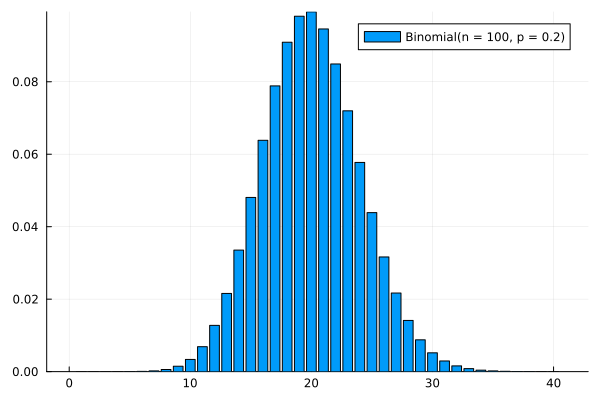

In [2]:
using Distributions, StatsPlots
using Pipe, HTTP, CSV, DataFrames, LsqFit
using PrettyTables
using Random
# using KittyTerminalImages
# KittyTerminalImages.forceKittyDisplay!()

d = Binomial(100, 0.2)  # number of trials, prob single trial
println(params(d))
println(mean(d))
println(var(d))
println(median(d))
println(rand(d))

rand(Xoshiro(123), d, (2, 3))
pdf(d, 20)
y = cdf(d, 25)
quantile(d, 0.91)
bar(x -> pdf(d, x), 1:40; label = "Binomial(n = 100, p = 0.2)")



Before getting into the sports betting example here is a fitting growth model using French forest data.

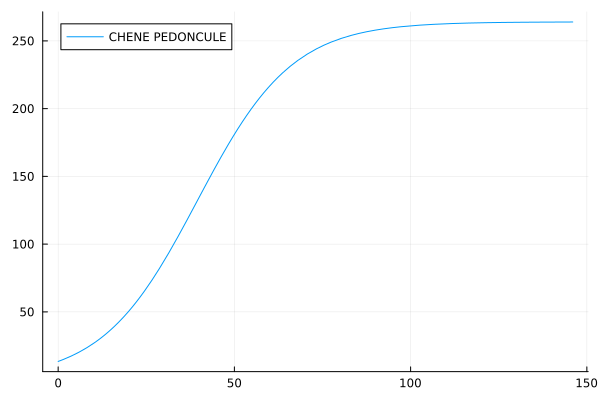

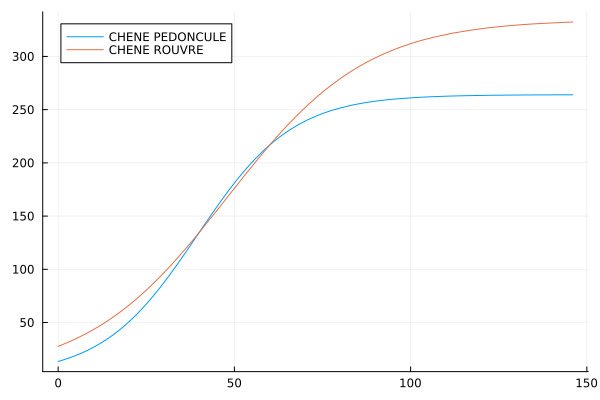

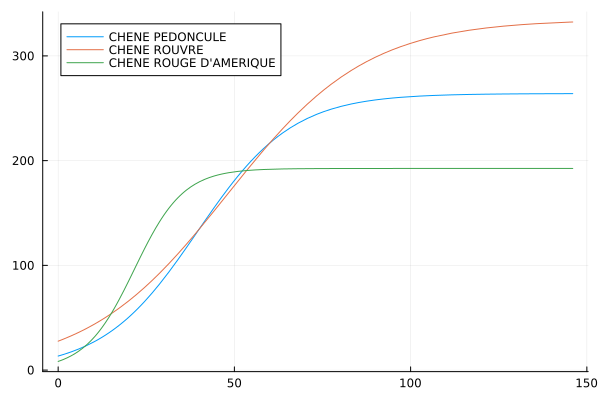

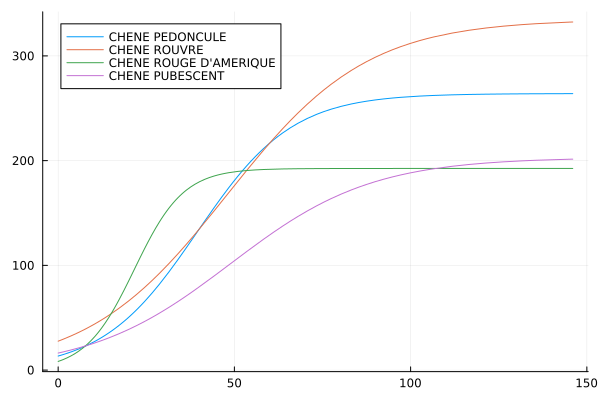

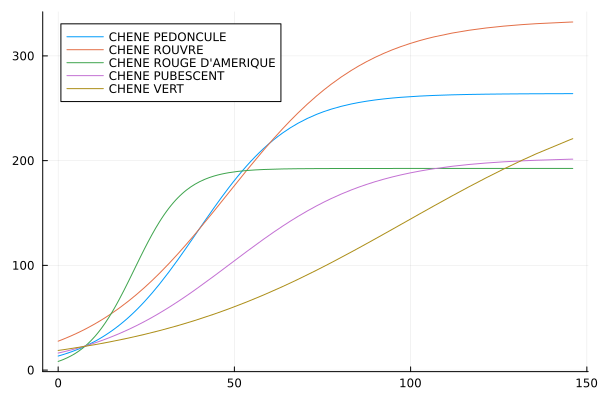

In [ ]:
Random.seed!(42)

ltURL = "https://bit.ly/apress_julia_alive_trees"
dtURL = "https://bit.ly/apress_julia_dead_trees"
ptsURL = "https://bit.ly/apress_julia_inv_points"
docURL = "https://bit.ly/apress_julia_inv_doc"

begin
    lt = @pipe HTTP.get(ltURL).body |> CSV.File(_) |> DataFrame
    dt = @pipe HTTP.get(dtURL).body |> CSV.File(_) |> DataFrame
    pts = @pipe HTTP.get(ptsURL).body |> CSV.File(_) |> DataFrame
    doc = @pipe HTTP.get(docURL).body |> CSV.File(_) |> DataFrame
    # lt = @pipe HTTP.get(ltURL).body |> CSV.File(_) |> DataFrames.pretty_table
    # dt = @pipe HTTP.get(dtURL).body |> CSV.File(_) |> DataFrames.pretty_table
    # pts = @pipe HTTP.get(ptsURL).body |> CSV.File(_) |> DataFrames.pretty_table
    # doc = @pipe HTTP.get(docURL).body |> CSV.File(_) |> DataFrames.pretty_table
end

# filtering
lt = lt[:, ["idp", "c13", "v"]]
dt = dt[:, ["idp", "c13", "v"]]
trees = vcat(lt, dt)
pts = pts[:, ["idp", "esspre", "cac"]]

# compute the timber volumes per hectare

"""
    vHaContribution(volume,circumference)

Return the contribution in terms of m³/ha of the tree.

The French inventory system is based on a concentric sample method: small trees are sampled on a small area (6 metres radius), intermediate trees on a concentric area of 9 metres and only large trees (with a circonference larger than 117.5 cm) are sampled on a concentric area of 15 metres of radius.
This function normalise the contribution of each tree to m³/ha.
"""
function vHaContribution(v, c13)
    if c13 < 70.5
        return v / (6^2 * pi / (100 * 100))
    elseif c13 < 117.5
        return v / (9^2 * pi / (100 * 100))
    else
        return v / (15^2 * pi / (100 * 100))
    end
end

trees.vHa = vHaContribution.(trees.v, trees.c13)

# aggregation annhilation
ptsVols = combine(groupby(trees, ["idp"]), "vHa" => sum => "vHa", nrow => "ntrees")

# join all the things
pts = innerjoin(pts, ptsVols; on = "idp")

# filter duece duece
filter_nTrees = pts.ntrees .> 5   # we skip points with few trees
filter_IHaveAgeClass = .!in.(pts.cac, Ref(["AA", "NR"]))
filter_IHaveMainSpecies = .!ismissing.(pts.esspre)
filter_overall = filter_nTrees .&& filter_IHaveAgeClass .&& filter_IHaveMainSpecies
pts = pts[filter_overall, :]

# computing age class
pts.cac = (parse.(Int64, pts.cac) .- 1) .* 5 .+ 2.5

# defining the model to fit
logisticModel(age, params) = params[1] / (1 + exp(-params[2] * (age - params[3])))
logisticModelVec(age, params) = logisticModel.(age, Ref(params))

# setting initial values for the params to fit
init_params = [1_000, 0.05, 50]  # max growth; growth rate; mid age

# fitting model
fit_obj = curve_fit(logisticModelVec, pts.cac, pts.vHa, init_params)
fit_params = fit_obj.param

# computting errors
fit_obj.resid

σ = stderror(fit_obj)
CI = confidence_interval(fit_obj, 0.1)  # 10% significance level

# plot!
x = 0:(maximum(pts.cac)*1.5)
plot(
    x -> logisticModel(x, fit_params),
    0,
    maximum(x);
    label = "Fitted vols",
    legend = :topleft,
)

# add obs to the plot
plot!(pts.cac, pts.vHa; seriestype = :scatter, label = "Obs vHa")

# differentiating the model per tree species
species_cnt = combine(groupby(pts, :esspre), nrow => :count)
sort!(species_cnt, "count"; rev = true)

sp_label = doc[doc.donnee .== "ESSPRE", :]
sp_label.sp_code = parse.(Int64, sp_label.code)
species_cnt = leftjoin(species_cnt, sp_label; on = "esspre" => "sp_code")

# plotting the 5 main species separately

for (i, sp) in enumerate(species_cnt[1:5, "esspre"])
    local fit_obj, fit_params, x
    sp_label = species_cnt[i, "libelle"]
    pts_sp = pts[pts.esspre .== sp, :]
    fit_obj = curve_fit(logisticModelVec, pts_sp.cac, pts_sp.vHa, init_params)
    fit_params = fit_obj.param
    x = 0:(maximum(pts.cac)*1.5)

    if i == 1
        myplot = plot(
            x -> logisticModel(x, fit_params),
            0,
            maximum(x);
            label = sp_label,
            legend = :topleft,
        )
    else
        myplot = plot!(
            x -> logisticModel(x, fit_params),
            0,
            maximum(x);
            label = sp_label,
            legend = :topleft,
        )
    end
    display(myplot)
end


<!-- move the above code to a separate notebook -->

In a soccer match, goals are few, occur and are counted, discretely. Typical example:

| goals  | probability |
| ---    | ----------- |
| 0      | high        |
| 1      | high        |
| 2      | medium      |
| 3      | low         |
| 4+     | very low    |

Thus the probability of scoring (k) goals is:

$$
\begin{aligned}
    &\mathcal{P}_{\lambda}(k) = \frac{\lambda^{k}}{k!} \exp^{-\lambda} \enspace \text{for each } k \in \mathbb{N} \\
&\text{where: } \\
    &\bullet (\lambda) = \text{ average goals } \\
    &\bullet (k) = \text{ number of goals }
\end{aligned}
$$

For example:
$\text{if } (\lambda = 1.5)$

| goals  | probability |
| ---    | ----------- |
| 0      | 22%         |
| 1      | 33%         |
| 2      | 25%         |
| 3      | 12%         |

A distribution very similar to real soccer data.

The outcome probability matrix relating to scores $0-0, 1-0, 2-1, \text{etc.}$ is the most used in soccer models. For example, the element $(1,0)$ of the matrix is ​​given by the probability that the home team scores 1 goal, knowing that its average goal total is $\lambda  = 1.6$ according to the relevant Poisson probability, multiplied by the probability that the away team scores 0 goals, knowing that its average goal total is $\lambda = 1.1$ according to the relevant Poisson probability. So essentially, you need to multiply the values ​​of two separate Poisson probability matrices. In the basic model, it is assumed that the home team's goals and the away team's goals are independent, so the probabilities multiply: $\mathcal{P}(i,j) = \mathcal{P}(i) \times \mathcal{P}(j)$.

The resulting matrix becomes, for example:


| .. | 0    | 1    | 2    | 3   |
| - | ---- | ---- | ---- | --- |
| 0 | 0.07 | 0.08 | 0.04 | ... |
| 1 | 0.10 | 0.11 | 0.06 | ... |
| 2 | 0.08 | 0.09 | 0.05 | ... |


So the outcome $(0, 1)$ has a probability of $8\%$, etc.


The **expected value of the bet** is the most important calculation because it indicates how much you win or lose on average with each bet.

$EV = (\mathcal{P} \times \text{Odds} - 1)$
Where $\mathcal{P}$ = estimated true probability and $\text{Odds}$ = bookmaker's odds.

For example, if the estimated probability is $50\%$ and the odds are $2.50$:

$EV = (0.50 \times 2.50) - 1 = +0.25$, it is a theoretically profitable bet, because you theoretically earn $\$0.25$ for every two dollars wagered on average.

So:

| EV     | meaning                      |
| ------ | ---------------------------- |
| EV > 0 | theoretically profitable bet |
| EV = 0 | fair game                    |
| EV < 0 | unfavorable bet              |


### True Implementation in Julia:

In [ ]:
max_goals = 5
matrix = [(i, j) for i = 0:max_goals, j = 0:max_goals]
# using PrettyTables
print(matrix)
println("\n")
println("--------------------------------------------------------------------------")
println("\n")
pretty_table(matrix)


[(0, 0) (0, 1) (0, 2) (0, 3) (0, 4) (0, 5); (1, 0) (1, 1) (1, 2) (1, 3) (1, 4) (1, 5); (2, 0) (2, 1) (2, 2) (2, 3) (2, 4) (2, 5); (3, 0) (3, 1) (3, 2) (3, 3) (3, 4) (3, 5); (4, 0) (4, 1) (4, 2) (4, 3) (4, 4) (4, 5); (5, 0) (5, 1) (5, 2) (5, 3) (5, 4) (5, 5)]

--------------------------------------------------------------------------


┌────────┬────────┬────────┬────────┬────────┬────────┐
│ Col. 1 │ Col. 2 │ Col. 3 │ Col. 4 │ Col. 5 │ Col. 6 │
├────────┼────────┼────────┼────────┼────────┼────────┤
│ (0, 0) │ (0, 1) │ (0, 2) │ (0, 3) │ (0, 4) │ (0, 5) │
│ (1, 0) │ (1, 1) │ (1, 2) │ (1, 3) │ (1, 4) │ (1, 5) │
│ (2, 0) │ (2, 1) │ (2, 2) │ (2, 3) │ (2, 4) │ (2, 5) │
│ (3, 0) │ (3, 1) │ (3, 2) │ (3, 3) │ (3, 4) │ (3, 5) │
│ (4, 0) │ (4, 1) │ (4, 2) │ (4, 3) │ (4, 4) │ (4, 5) │
│ (5, 0) │ (5, 1) │ (5, 2) │ (5, 3) │ (5, 4) │ (5, 5) │
└────────┴────────┴────────┴────────┴────────┴────────┘


In [ ]:
λₕ = 1.6
λₐ = 1.1

goalsₕ = Poisson(λₕ)
goalsₐ = Poisson(λₐ)

prob_matrix = zeros(max_goals + 1, max_goals + 1)

for i = 0:max_goals
    for j = 0:max_goals
        prob_matrix[i+1, j+1] = pdf(goalsₕ, i) * pdf(goalsₐ, j)
    end
end

pretty_table(prob_matrix)


┌────────────┬────────────┬────────────┬────────────┬─────────────┬─────────────┐
│     Col. 1 │     Col. 2 │     Col. 3 │     Col. 4 │      Col. 5 │      Col. 6 │
├────────────┼────────────┼────────────┼────────────┼─────────────┼─────────────┤
│  0.0672055 │  0.0739261 │  0.0406593 │  0.0149084 │  0.00409982 │  0.00090196 │
│   0.107529 │   0.118282 │  0.0650549 │  0.0238535 │  0.00655971 │  0.00144314 │
│  0.0860231 │  0.0946254 │  0.0520439 │  0.0190828 │  0.00524776 │  0.00115451 │
│   0.045879 │  0.0504669 │  0.0277568 │  0.0101775 │  0.00279881 │ 0.000615738 │
│  0.0183516 │  0.0201867 │  0.0111027 │ 0.00407099 │  0.00111952 │ 0.000246295 │
│ 0.00587251 │ 0.00645976 │ 0.00355287 │ 0.00130272 │ 0.000358247 │  7.88144e-5 │
└────────────┴────────────┴────────────┴────────────┴─────────────┴─────────────┘


In [ ]:
pₕ::Float64 = 0.0
p₀::Float64 = 0.0
pₐ::Float64 = 0.0

for i = 0:max_goals
    for j = 0:max_goals
        p = prob_matrix[i+1, j+1]

        if i > j
            pₕ += p
        elseif i == j
            p₀ += p
        else
            pₐ += p
        end
    end
end

println("Home win probability: ", pₕ)
println("Draw probability: ", p₀)
println("Away win probability: ", pₐ)


Home win probability: 0.48353796379688296
Draw probability: 0.24890698520246393
Away win probability: 0.260552747649295


So a home win is more likely by $\sim48.35\%$.

Lets assume the following bookmaker odds and calculate the expected value:
- $pₕ$ (home) = 2.3
- $p₀$ (draw) = 3.4
- $pₐ$ (away) = 3.1

In [ ]:
oddsₕ::Float64 = 2.3
odds₀::Float64 = 3.4
oddsₐ::Float64 = 3.1

EVₕ = pₕ * oddsₕ - 1
EV₀ = p₀ * odds₀ - 1
EVₐ = pₐ * oddsₐ - 1

println("EV home: ", EVₕ)
println("EV draw: ", EV₀)
println("EV away: ", EVₐ)


EV home: 0.11213731673283078
EV draw: -0.15371625031162262
EV away: -0.1922864822871856


Then:
- home $→$ favorable
- draw $→$ unfavorable
- away $→$ unfavorable

```mermaid
flowchart LR
    Home --> favorable
    Draw --> unfavorable
    Away --> unfavorable
```

We can also find the most likely (exact) result:

In [ ]:
max_prob = 0
score = (0, 0)

for i = 0:max_goals
    for j = 0:max_goals
        p = prob_matrix[i+1, j+1]

        if p > max_prob
            max_prob = p
            score = (i, j)
        end
    end
end

println("Most likely result: ", score)
println("Probability: ", max_prob)


Most likely result: (1, 1)
Probability: 0.1182817024219596


### Estimate of $\lambda$ (goal averages) with Series A data

The data will have columns like this:

| Date       | HomeTeam | AwayTeam | FTHG | FTAG |
| ---------- | -------- | -------- | ---- | ---- |
| 2023-08-19 | Empoli   | Verona   | 0    | 1    |

- FTHG = Full Time Home Goals
- FTAG = Full Time Away Goals

^[football-data.co.uk](https://www.football-data.co.uk/mmz4281/2324/I1.csv)^

In [ ]:
series_a = "https://www.football-data.co.uk/mmz4281/2324/I1.csv"


"https://www.football-data.co.uk/mmz4281/2324/I1.csv"

In [ ]:
# df = CSV.read("/Users/eo/Downloads/I1.csv", DataFrame)
# series_a = "https://www.football-data.co.uk/mmz4281/2324/I1.csv"

temp = @pipe HTTP.get(series_a).body |> CSV.File(_) |> DataFrame
# @pipe HTTP.get(series_a).body |> CSV.File(_) |> DataFrame


Row,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,B365H,B365D,B365A,BWH,BWD,BWA,IWH,IWD,IWA,PSH,PSD,PSA,WHH,WHD,WHA,VCH,VCD,VCA,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,B365>2.5,B365<2.5,P>2.5,P<2.5,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,AHh,B365AHH,B365AHA,PAHH,PAHA,MaxAHH,MaxAHA,AvgAHH,AvgAHA,B365CH,B365CD,B365CA,BWCH,BWCD,BWCA,IWCH,IWCD,IWCA,PSCH,PSCD,PSCA,WHCH,WHCD,WHCA,VCCH,VCCD,VCCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,B365C>2.5,B365C<2.5,PC>2.5,PC<2.5,MaxC>2.5,MaxC<2.5,AvgC>2.5,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,⋯
,String3,String15,Time,String15,String15,Int64,Int64,String1,Int64,Int64,String1,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Float64,Float64,Float64,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,⋯
1,I1,19/08/2023,17:30:00,Empoli,Verona,0,1,A,0,0,D,10,10,4,4,17,18,2,4,2,2,0,0,2.25,3.2,3.3,2.35,3.25,3.1,2.3,3.25,3.2,2.3,3.3,3.44,2.25,3.0,2.88,2.25,3.1,3.4,2.38,3.5,3.45,2.3,3.28,3.27,2.1,1.73,2.13,1.78,2.18,1.8,2.11,1.74,-0.25,1.97,1.93,1.96,1.94,2.0,1.97,1.95,1.9,2.25,3.3,3.25,2.25,3.3,3.2,2.3,3.35,3.2,2.34,3.42,3.3,2.15,3.0,3.1,2.3,3.2,3.2,2.35,3.5,3.54,2.26,3.35,3.23,2.0,1.9,2.03,1.88,2.13,1.96,1.96,1.85,-0.25,2.02,1.91,2.01,⋯
2,I1,19/08/2023,17:30:00,Frosinone,Napoli,1,3,A,1,2,A,4,19,1,8,14,17,4,6,3,3,0,0,8.5,5.0,1.36,8.25,5.0,1.36,8.25,5.25,1.37,8.85,5.25,1.37,8.5,4.5,1.25,10.0,4.8,1.33,10.0,5.51,1.4,8.79,5.12,1.36,1.67,2.2,1.71,2.22,1.74,2.28,1.68,2.2,1.5,1.84,2.06,1.83,2.09,1.89,2.11,1.83,2.03,6.5,4.33,1.55,5.75,4.2,1.55,6.0,4.4,1.53,6.36,4.36,1.56,5.8,4.2,1.4,6.0,3.8,1.5,6.91,4.75,1.57,6.15,4.37,1.53,1.73,2.1,1.79,2.12,1.83,2.23,1.75,2.1,1.0,1.96,1.97,1.97,⋯
3,I1,19/08/2023,19:45:00,Genoa,Fiorentina,1,4,A,0,3,A,4,9,2,5,14,13,3,4,2,3,0,0,3.4,3.25,2.2,3.25,3.3,2.25,3.35,3.35,2.2,3.54,3.36,2.23,3.0,3.1,2.15,3.6,3.13,2.15,3.6,3.54,2.27,3.41,3.34,2.21,2.1,1.73,2.1,1.79,2.14,1.82,2.06,1.77,0.25,2.0,1.9,2.0,1.91,2.02,1.92,1.96,1.88,3.0,3.2,2.45,3.1,3.2,2.37,3.4,3.3,2.2,3.19,3.22,2.51,3.1,3.0,2.15,3.13,3.1,2.4,3.67,3.36,2.51,3.27,3.25,2.34,2.1,1.73,2.23,1.72,2.23,1.81,2.12,1.74,0.25,1.79,2.15,1.82,⋯
4,I1,19/08/2023,19:45:00,Inter,Monza,2,0,H,1,0,H,22,12,3,2,8,13,8,3,1,1,0,0,1.4,5.0,7.0,1.39,5.0,7.25,1.43,4.7,7.5,1.39,5.1,8.76,1.3,4.5,7.0,1.33,5.0,9.0,1.43,5.4,9.0,1.38,5.08,7.92,1.57,2.38,1.59,2.46,1.63,2.49,1.58,2.41,-1.25,1.83,2.07,1.82,2.07,1.86,2.1,1.82,2.03,1.4,5.0,7.0,1.42,4.8,7.0,1.43,4.6,7.5,1.41,5.16,7.81,1.3,4.6,7.5,1.33,4.6,8.5,1.44,5.5,8.5,1.4,4.99,7.62,1.57,2.38,1.6,2.44,1.63,2.53,1.59,2.38,-1.25,1.92,2.01,1.91,⋯
5,I1,20/08/2023,17:30:00,Roma,Salernitana,2,2,D,1,1,D,13,3,3,2,12,9,9,1,0,4,0,0,1.53,4.0,6.5,1.53,4.0,6.5,1.55,3.95,6.5,1.53,4.18,7.16,1.44,3.75,6.0,1.45,3.7,7.0,1.58,4.33,7.5,1.53,4.07,6.83,2.1,1.73,2.16,1.76,2.18,1.81,2.1,1.75,-1.0,1.93,1.97,1.93,1.98,1.96,2.04,1.92,1.93,1.5,4.0,7.5,1.51,3.9,7.25,1.55,3.9,6.75,1.54,4.08,7.65,1.44,3.5,6.5,1.45,3.9,8.0,1.59,4.15,8.13,1.52,3.95,7.34,2.2,1.67,2.27,1.7,2.28,1.75,2.2,1.68,-1.0,1.95,1.98,1.94,⋯
6,I1,20/08/2023,17:30:00,Sassuolo,Atalanta,0,2,A,0,0,D,11,16,3,6,9,13,7,7,0,0,0,0,3.5,3.4,2.1,3.25,3.6,2.1,3.35,3.6,2.1,3.39,3.63,2.18,3.2,3.3,1.95,3.3,3.4,2.0,3.65,3.8,2.2,3.35,3.62,2.12,1.62,2.3,1.63,2.38,1.68,2.43,1.62,2.33,0.25,2.03,1.87,2.02,1.89,2.08,1.89,2.01,1.84,3.25,3.5,2.2,3.2,3.6,2.15,3.35,3.6,2.1,3.53,3.64,2.15,3.2,3.3,1.95,3.13,3.4,2.25,3.6,3.77,2.27,3.35,3.62,2.13,1.73,2.1,1.75,2.19,1.75,2.43,1.67,2.23,0.25,2.04,1.89,2.07,⋯
7,I1,20/

In [ ]:
# df = CSV.read("/Users/eo/Downloads/I1.csv", DataFrame)
series_a = "https://www.football-data.co.uk/mmz4281/2324/I1.csv"

@pipe HTTP.get(series_a).body |> CSV.File(_) |> DataFrame


Row,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,B365H,B365D,B365A,BWH,BWD,BWA,IWH,IWD,IWA,PSH,PSD,PSA,WHH,WHD,WHA,VCH,VCD,VCA,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,B365>2.5,B365<2.5,P>2.5,P<2.5,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,AHh,B365AHH,B365AHA,PAHH,PAHA,MaxAHH,MaxAHA,AvgAHH,AvgAHA,B365CH,B365CD,B365CA,BWCH,BWCD,BWCA,IWCH,IWCD,IWCA,PSCH,PSCD,PSCA,WHCH,WHCD,WHCA,VCCH,VCCD,VCCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,B365C>2.5,B365C<2.5,PC>2.5,PC<2.5,MaxC>2.5,MaxC<2.5,AvgC>2.5,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,⋯
,String3,String15,Time,String15,String15,Int64,Int64,String1,Int64,Int64,String1,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Float64,Float64,Float64,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,⋯
1,I1,19/08/2023,17:30:00,Empoli,Verona,0,1,A,0,0,D,10,10,4,4,17,18,2,4,2,2,0,0,2.25,3.2,3.3,2.35,3.25,3.1,2.3,3.25,3.2,2.3,3.3,3.44,2.25,3.0,2.88,2.25,3.1,3.4,2.38,3.5,3.45,2.3,3.28,3.27,2.1,1.73,2.13,1.78,2.18,1.8,2.11,1.74,-0.25,1.97,1.93,1.96,1.94,2.0,1.97,1.95,1.9,2.25,3.3,3.25,2.25,3.3,3.2,2.3,3.35,3.2,2.34,3.42,3.3,2.15,3.0,3.1,2.3,3.2,3.2,2.35,3.5,3.54,2.26,3.35,3.23,2.0,1.9,2.03,1.88,2.13,1.96,1.96,1.85,-0.25,2.02,1.91,2.01,⋯
2,I1,19/08/2023,17:30:00,Frosinone,Napoli,1,3,A,1,2,A,4,19,1,8,14,17,4,6,3,3,0,0,8.5,5.0,1.36,8.25,5.0,1.36,8.25,5.25,1.37,8.85,5.25,1.37,8.5,4.5,1.25,10.0,4.8,1.33,10.0,5.51,1.4,8.79,5.12,1.36,1.67,2.2,1.71,2.22,1.74,2.28,1.68,2.2,1.5,1.84,2.06,1.83,2.09,1.89,2.11,1.83,2.03,6.5,4.33,1.55,5.75,4.2,1.55,6.0,4.4,1.53,6.36,4.36,1.56,5.8,4.2,1.4,6.0,3.8,1.5,6.91,4.75,1.57,6.15,4.37,1.53,1.73,2.1,1.79,2.12,1.83,2.23,1.75,2.1,1.0,1.96,1.97,1.97,⋯
3,I1,19/08/2023,19:45:00,Genoa,Fiorentina,1,4,A,0,3,A,4,9,2,5,14,13,3,4,2,3,0,0,3.4,3.25,2.2,3.25,3.3,2.25,3.35,3.35,2.2,3.54,3.36,2.23,3.0,3.1,2.15,3.6,3.13,2.15,3.6,3.54,2.27,3.41,3.34,2.21,2.1,1.73,2.1,1.79,2.14,1.82,2.06,1.77,0.25,2.0,1.9,2.0,1.91,2.02,1.92,1.96,1.88,3.0,3.2,2.45,3.1,3.2,2.37,3.4,3.3,2.2,3.19,3.22,2.51,3.1,3.0,2.15,3.13,3.1,2.4,3.67,3.36,2.51,3.27,3.25,2.34,2.1,1.73,2.23,1.72,2.23,1.81,2.12,1.74,0.25,1.79,2.15,1.82,⋯
4,I1,19/08/2023,19:45:00,Inter,Monza,2,0,H,1,0,H,22,12,3,2,8,13,8,3,1,1,0,0,1.4,5.0,7.0,1.39,5.0,7.25,1.43,4.7,7.5,1.39,5.1,8.76,1.3,4.5,7.0,1.33,5.0,9.0,1.43,5.4,9.0,1.38,5.08,7.92,1.57,2.38,1.59,2.46,1.63,2.49,1.58,2.41,-1.25,1.83,2.07,1.82,2.07,1.86,2.1,1.82,2.03,1.4,5.0,7.0,1.42,4.8,7.0,1.43,4.6,7.5,1.41,5.16,7.81,1.3,4.6,7.5,1.33,4.6,8.5,1.44,5.5,8.5,1.4,4.99,7.62,1.57,2.38,1.6,2.44,1.63,2.53,1.59,2.38,-1.25,1.92,2.01,1.91,⋯
5,I1,20/08/2023,17:30:00,Roma,Salernitana,2,2,D,1,1,D,13,3,3,2,12,9,9,1,0,4,0,0,1.53,4.0,6.5,1.53,4.0,6.5,1.55,3.95,6.5,1.53,4.18,7.16,1.44,3.75,6.0,1.45,3.7,7.0,1.58,4.33,7.5,1.53,4.07,6.83,2.1,1.73,2.16,1.76,2.18,1.81,2.1,1.75,-1.0,1.93,1.97,1.93,1.98,1.96,2.04,1.92,1.93,1.5,4.0,7.5,1.51,3.9,7.25,1.55,3.9,6.75,1.54,4.08,7.65,1.44,3.5,6.5,1.45,3.9,8.0,1.59,4.15,8.13,1.52,3.95,7.34,2.2,1.67,2.27,1.7,2.28,1.75,2.2,1.68,-1.0,1.95,1.98,1.94,⋯
6,I1,20/08/2023,17:30:00,Sassuolo,Atalanta,0,2,A,0,0,D,11,16,3,6,9,13,7,7,0,0,0,0,3.5,3.4,2.1,3.25,3.6,2.1,3.35,3.6,2.1,3.39,3.63,2.18,3.2,3.3,1.95,3.3,3.4,2.0,3.65,3.8,2.2,3.35,3.62,2.12,1.62,2.3,1.63,2.38,1.68,2.43,1.62,2.33,0.25,2.03,1.87,2.02,1.89,2.08,1.89,2.01,1.84,3.25,3.5,2.2,3.2,3.6,2.15,3.35,3.6,2.1,3.53,3.64,2.15,3.2,3.3,1.95,3.13,3.4,2.25,3.6,3.77,2.27,3.35,3.62,2.13,1.73,2.1,1.75,2.19,1.75,2.43,1.67,2.23,0.25,2.04,1.89,2.07,⋯
7,I1,20/

In [ ]:
df = deepcopy(temp)


Row,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,B365H,B365D,B365A,BWH,BWD,BWA,IWH,IWD,IWA,PSH,PSD,PSA,WHH,WHD,WHA,VCH,VCD,VCA,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,B365>2.5,B365<2.5,P>2.5,P<2.5,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,AHh,B365AHH,B365AHA,PAHH,PAHA,MaxAHH,MaxAHA,AvgAHH,AvgAHA,B365CH,B365CD,B365CA,BWCH,BWCD,BWCA,IWCH,IWCD,IWCA,PSCH,PSCD,PSCA,WHCH,WHCD,WHCA,VCCH,VCCD,VCCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,B365C>2.5,B365C<2.5,PC>2.5,PC<2.5,MaxC>2.5,MaxC<2.5,AvgC>2.5,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,⋯
,String3,String15,Time,String15,String15,Int64,Int64,String1,Int64,Int64,String1,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Float64,Float64,Float64,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,⋯
1,I1,19/08/2023,17:30:00,Empoli,Verona,0,1,A,0,0,D,10,10,4,4,17,18,2,4,2,2,0,0,2.25,3.2,3.3,2.35,3.25,3.1,2.3,3.25,3.2,2.3,3.3,3.44,2.25,3.0,2.88,2.25,3.1,3.4,2.38,3.5,3.45,2.3,3.28,3.27,2.1,1.73,2.13,1.78,2.18,1.8,2.11,1.74,-0.25,1.97,1.93,1.96,1.94,2.0,1.97,1.95,1.9,2.25,3.3,3.25,2.25,3.3,3.2,2.3,3.35,3.2,2.34,3.42,3.3,2.15,3.0,3.1,2.3,3.2,3.2,2.35,3.5,3.54,2.26,3.35,3.23,2.0,1.9,2.03,1.88,2.13,1.96,1.96,1.85,-0.25,2.02,1.91,2.01,⋯
2,I1,19/08/2023,17:30:00,Frosinone,Napoli,1,3,A,1,2,A,4,19,1,8,14,17,4,6,3,3,0,0,8.5,5.0,1.36,8.25,5.0,1.36,8.25,5.25,1.37,8.85,5.25,1.37,8.5,4.5,1.25,10.0,4.8,1.33,10.0,5.51,1.4,8.79,5.12,1.36,1.67,2.2,1.71,2.22,1.74,2.28,1.68,2.2,1.5,1.84,2.06,1.83,2.09,1.89,2.11,1.83,2.03,6.5,4.33,1.55,5.75,4.2,1.55,6.0,4.4,1.53,6.36,4.36,1.56,5.8,4.2,1.4,6.0,3.8,1.5,6.91,4.75,1.57,6.15,4.37,1.53,1.73,2.1,1.79,2.12,1.83,2.23,1.75,2.1,1.0,1.96,1.97,1.97,⋯
3,I1,19/08/2023,19:45:00,Genoa,Fiorentina,1,4,A,0,3,A,4,9,2,5,14,13,3,4,2,3,0,0,3.4,3.25,2.2,3.25,3.3,2.25,3.35,3.35,2.2,3.54,3.36,2.23,3.0,3.1,2.15,3.6,3.13,2.15,3.6,3.54,2.27,3.41,3.34,2.21,2.1,1.73,2.1,1.79,2.14,1.82,2.06,1.77,0.25,2.0,1.9,2.0,1.91,2.02,1.92,1.96,1.88,3.0,3.2,2.45,3.1,3.2,2.37,3.4,3.3,2.2,3.19,3.22,2.51,3.1,3.0,2.15,3.13,3.1,2.4,3.67,3.36,2.51,3.27,3.25,2.34,2.1,1.73,2.23,1.72,2.23,1.81,2.12,1.74,0.25,1.79,2.15,1.82,⋯
4,I1,19/08/2023,19:45:00,Inter,Monza,2,0,H,1,0,H,22,12,3,2,8,13,8,3,1,1,0,0,1.4,5.0,7.0,1.39,5.0,7.25,1.43,4.7,7.5,1.39,5.1,8.76,1.3,4.5,7.0,1.33,5.0,9.0,1.43,5.4,9.0,1.38,5.08,7.92,1.57,2.38,1.59,2.46,1.63,2.49,1.58,2.41,-1.25,1.83,2.07,1.82,2.07,1.86,2.1,1.82,2.03,1.4,5.0,7.0,1.42,4.8,7.0,1.43,4.6,7.5,1.41,5.16,7.81,1.3,4.6,7.5,1.33,4.6,8.5,1.44,5.5,8.5,1.4,4.99,7.62,1.57,2.38,1.6,2.44,1.63,2.53,1.59,2.38,-1.25,1.92,2.01,1.91,⋯
5,I1,20/08/2023,17:30:00,Roma,Salernitana,2,2,D,1,1,D,13,3,3,2,12,9,9,1,0,4,0,0,1.53,4.0,6.5,1.53,4.0,6.5,1.55,3.95,6.5,1.53,4.18,7.16,1.44,3.75,6.0,1.45,3.7,7.0,1.58,4.33,7.5,1.53,4.07,6.83,2.1,1.73,2.16,1.76,2.18,1.81,2.1,1.75,-1.0,1.93,1.97,1.93,1.98,1.96,2.04,1.92,1.93,1.5,4.0,7.5,1.51,3.9,7.25,1.55,3.9,6.75,1.54,4.08,7.65,1.44,3.5,6.5,1.45,3.9,8.0,1.59,4.15,8.13,1.52,3.95,7.34,2.2,1.67,2.27,1.7,2.28,1.75,2.2,1.68,-1.0,1.95,1.98,1.94,⋯
6,I1,20/08/2023,17:30:00,Sassuolo,Atalanta,0,2,A,0,0,D,11,16,3,6,9,13,7,7,0,0,0,0,3.5,3.4,2.1,3.25,3.6,2.1,3.35,3.6,2.1,3.39,3.63,2.18,3.2,3.3,1.95,3.3,3.4,2.0,3.65,3.8,2.2,3.35,3.62,2.12,1.62,2.3,1.63,2.38,1.68,2.43,1.62,2.33,0.25,2.03,1.87,2.02,1.89,2.08,1.89,2.01,1.84,3.25,3.5,2.2,3.2,3.6,2.15,3.35,3.6,2.1,3.53,3.64,2.15,3.2,3.3,1.95,3.13,3.4,2.25,3.6,3.77,2.27,3.35,3.62,2.13,1.73,2.1,1.75,2.19,1.75,2.43,1.67,2.23,0.25,2.04,1.89,2.07,⋯
7,I1,20/

In [ ]:
println(supertype(typeof(df)))
println("-----------------")
println(typeof(df))


AbstractDataFrame
-----------------
DataFrame


In [28]:
df = select(df, :HomeTeam, :AwayTeam, :FTHG, :FTAG)

rename!(df, :FTHG => :HomeGoals, :FTAG => :AwayGoals)

dropmissing!(df)


Row,HomeTeam,AwayTeam,HomeGoals,AwayGoals
,String15,String15,Int64,Int64
1,Empoli,Verona,0,1
2,Frosinone,Napoli,1,3
3,Genoa,Fiorentina,1,4
4,Inter,Monza,2,0
5,Roma,Salernitana,2,2
6,Sassuolo,Atalanta,0,2
7,Lecce,Lazio,2,1
8,Udinese,Juventus,0,3
9,Torino,Cagliari,0,0


In [33]:
teams = unique(vcat(df.HomeTeam, df.AwayTeam))


20-element Vector{String15}:
 "Empoli"
 "Frosinone"
 "Genoa"
 "Inter"
 "Roma"
 "Sassuolo"
 "Lecce"
 "Udinese"
 "Torino"
 "Bologna"
 "Monza"
 "Milan"
 "Verona"
 "Fiorentina"
 "Juventus"
 "Lazio"
 "Napoli"
 "Salernitana"
 "Cagliari"
 "Atalanta"

In [34]:
# build a dataset with **goals scored & conceded**:
stats = DataFrame(
    team = teams,
    goals_scored = zeros(length(teams)),
    goals_granted = zeros(length(teams)),
    matches = zeros(Int, length(teams)),
)


Row,team,goals_scored,goals_granted,matches
,String15,Float64,Float64,Int64
1,Empoli,0.0,0.0,0
2,Frosinone,0.0,0.0,0
3,Genoa,0.0,0.0,0
4,Inter,0.0,0.0,0
5,Roma,0.0,0.0,0
6,Sassuolo,0.0,0.0,0
7,Lecce,0.0,0.0,0
8,Udinese,0.0,0.0,0
9,Torino,0.0,0.0,0


In [36]:
# calculating averages

for row in eachrow(df)
    home = row.HomeTeam
    away = row.AwayTeam

    hg = row.HomeGoals
    ag = row.AwayGoals

    stats[stats.team .== home, :goals_scored] .+= hg
    stats[stats.team .== home, :goals_granted] .+= ag
    stats[stats.team .== home, :matches] .+= 1

    stats[stats.team .== away, :goals_scored] .+= ag
    stats[stats.team .== away, :goals_granted] .+= hg
    stats[stats.team .== away, :matches] .+= 1
end


In [37]:
# Average goals (lambda)
stats.lambda_attack = stats.goals_scored ./ stats.matches
stats.lambda_defense = stats.goals_granted ./ stats.matches


20-element Vector{Float64}:
 1.4210526315789473
 1.8157894736842106
 1.1842105263157894
 0.5789473684210527
 1.2105263157894737
 1.9736842105263157
 1.4210526315789473
 1.394736842105263
 0.9473684210526315
 0.8421052631578947
 1.3421052631578947
 1.2894736842105263
 1.3421052631578947
 1.2105263157894737
 0.8157894736842105
 1.0263157894736843
 1.263157894736842
 2.1315789473684212
 1.7894736842105263
 1.105263157894737

| team  | attack λ | defense λ |
| ----- | -------- | --------- |
| Inter | 1.9      | 0.8       |
| Milan | 1.6      | 1.0       |
| Roma  | 1.4      | 1.2       |

In [38]:
team_home = "Inter"
team_away = "Milan"


"Milan"

In [39]:
lambda_home = stats[stats.team .== team_home, :lambda_attack][1]
lambda_away = stats[stats.team .== team_away, :lambda_attack][1]


2.0

In [41]:
println("lambda_home = ", lambda_home)
println("lambda_away = ", lambda_away)


lambda_home = 2.3421052631578947
lambda_away = 2.0
